In [295]:
# Verify we hold the correct file context
print("File context verified.")

File context verified.


In [296]:
%pip install gensim
%pip install imbalanced-learn
%pip install pandas
%pip install openai python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [297]:
import pandas as pd
df = pd.read_csv("cleaned_file.csv", on_bad_lines='skip')

df.head()

,payload,classification
0,sullivanjj@state.gov,high
1,"Koh, Harold Hongju",high
2,"Dear customer, you have 16,590 points which wi...",low
3,mark.guzman@enron.com,high
4,"icd_code=0090, icd_version=9, diagnosis=Infect...",high


In [298]:
df = df.rename(columns={
    df.columns[0]: 'Tag',
    df.columns[1]: 'Sensitivity'
})

df['Sensitivity'] = (
    df['Sensitivity']
        .astype(str)          # ensure string
        .str.strip()          # remove spaces
        .str.capitalize()     # High / Low format
)




In [299]:
print(df['Sensitivity'].value_counts())

Sensitivity
High    5876
Low     4425
Name: count, dtype: int64


In [300]:
print(df['Sensitivity'].unique())
print(df['Tag'].nunique())


['High' 'Low']
9393


In [301]:
df = df.dropna(subset=['Sensitivity'])
df = df.drop_duplicates(subset='Tag', keep=False)

df.shape[0]

print(df['Sensitivity'].unique())
print(df['Tag'].nunique())


['High' 'Low']
9006


In [302]:
import re


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)               # just remove numbers
    text = re.sub(r'[=;:/\\._-]', ' ', text)       # Tokenize on symbols
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [303]:
from sklearn.model_selection import train_test_split

X = df['Tag']
y = df['Sensitivity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (7204,)
Shape of X_test: (1802,)
Shape of y_train: (7204,)
Shape of y_test: (1802,)


In [304]:
print(X_train)

2036    UPS: Your package requires teriyaki sauce appr...
9792    cfips=13179; name=Liberty; long=-81.49463778; ...
5056    icd_code: G35, icd_version: 10, diagnosis: Mul...
8586    icd_code=Z31.63, icd_version=10, diagnosis=Enc...
1435    Your Twitter Circle new members. Welcome: http...
                              ...                        
589     UPS: Your package requires age verification. V...
1734    patient: Sarah Wilson, condition: Hyperornithi...
2465    Your AT&T wireless service has been suspended....
4433    $7,800 BlueStar Range! Claim: http://bluestar-...
2572                                     O'Neil, Claire T
Name: Tag, Length: 7204, dtype: object


In [305]:
X_train_sample = X_train.apply(preprocess_text)
print (X_train_sample)

2036    ups your package requires teriyaki sauce appra...
9792                          cfips name liberty long lat
5056    icd code g, icd version , diagnosis multiple s...
8586    icd code z , icd version , diagnosis encounter...
1435    your twitter circle new members welcome http t...
                              ...                        
589     ups your package requires age verification ver...
1734    patient sarah wilson, condition hyperornithine...
2465    your at&t wireless service has been suspended ...
4433    $, bluestar range! claim http bluestar range g...
2572                                     o'neil, claire t
Name: Tag, Length: 7204, dtype: object


In [306]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.preprocessing import FunctionTransformer
from imblearn.over_sampling import SMOTE


count_vectorizer = CountVectorizer(
    analyzer='char_wb',
    ngram_range=(3,5),
    max_features=5000,
    min_df=2,
    preprocessor=preprocess_text
)

# Vectorization and SMOTE are done outside of the pipeline for fitting on the entire dataset
X_vectorized = count_vectorizer.fit_transform(df['Tag'])

smote = SMOTE(random_state=42) #try with no oversampling
X_resampled, y_resampled = smote.fit_resample(X_vectorized, df['Sensitivity'])

print(pd.Series(y_resampled).value_counts())

Sensitivity
High    4875
Low     4875
Name: count, dtype: int64


[(' , ', 6092), (' co', 4183), (' pa', 3753), ('on ', 3039), (' re', 2938), ('ng ', 2767), ('ion', 2744), ('ati', 2639), ('er ', 2585), (' ht', 2471), ('htt', 2405), ('ttp', 2405), (' htt', 2405), (' http', 2405), ('http', 2405), ('ent', 2378), ('nt ', 2367), ('ps ', 2296), (' se', 2271), ('al ', 2201)]


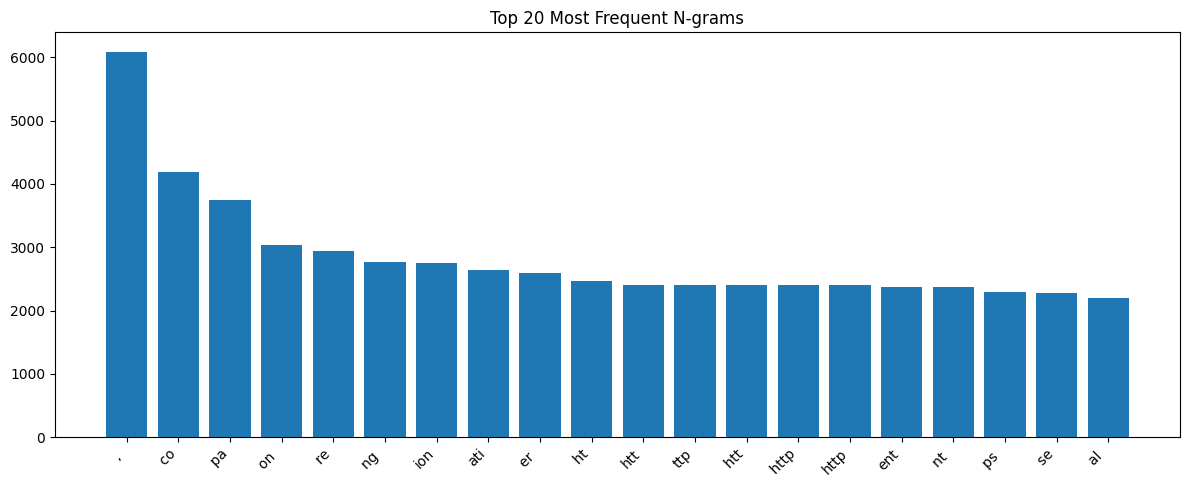

In [307]:
import matplotlib.pyplot as plt

ngram_freq = X_vectorized.sum(axis=0).A1
ngram_names = count_vectorizer.get_feature_names_out()

top_n = 20
top_idx = ngram_freq.argsort()[::-1][:top_n]

top_ngrams = [(ngram_names[i], ngram_freq[i]) for i in top_idx]
print(top_ngrams)

plt.figure(figsize=(12, 5))
plt.bar(ngram_names[top_idx], ngram_freq[top_idx])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent N-grams')
plt.tight_layout()
plt.show()

In [308]:



clf_pipeline_cv = Pipeline([
    ("count_vectorizer", count_vectorizer),
    ("clf", DecisionTreeClassifier(random_state=38))
])

clf_pipeline_cv.fit(X_train, y_train)

y_pred_cv = clf_pipeline_cv.predict(X_test)
print(classification_report(y_test, y_pred_cv))

# Calculate and print F1-score and accuracy for Decision Tree
dt_f1_macro = f1_score(y_test, y_pred_cv, average='macro')
dt_accuracy = accuracy_score(y_test, y_pred_cv)
print(f"Decision Tree Macro F1-score: {dt_f1_macro:.6f}")
print(f"Decision Tree Accuracy: {dt_accuracy:.6f}")

              precision    recall  f1-score   support

        High       0.99      0.99      0.99       975
         Low       0.99      0.99      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802

Decision Tree Macro F1-score: 0.991057
Decision Tree Accuracy: 0.991121


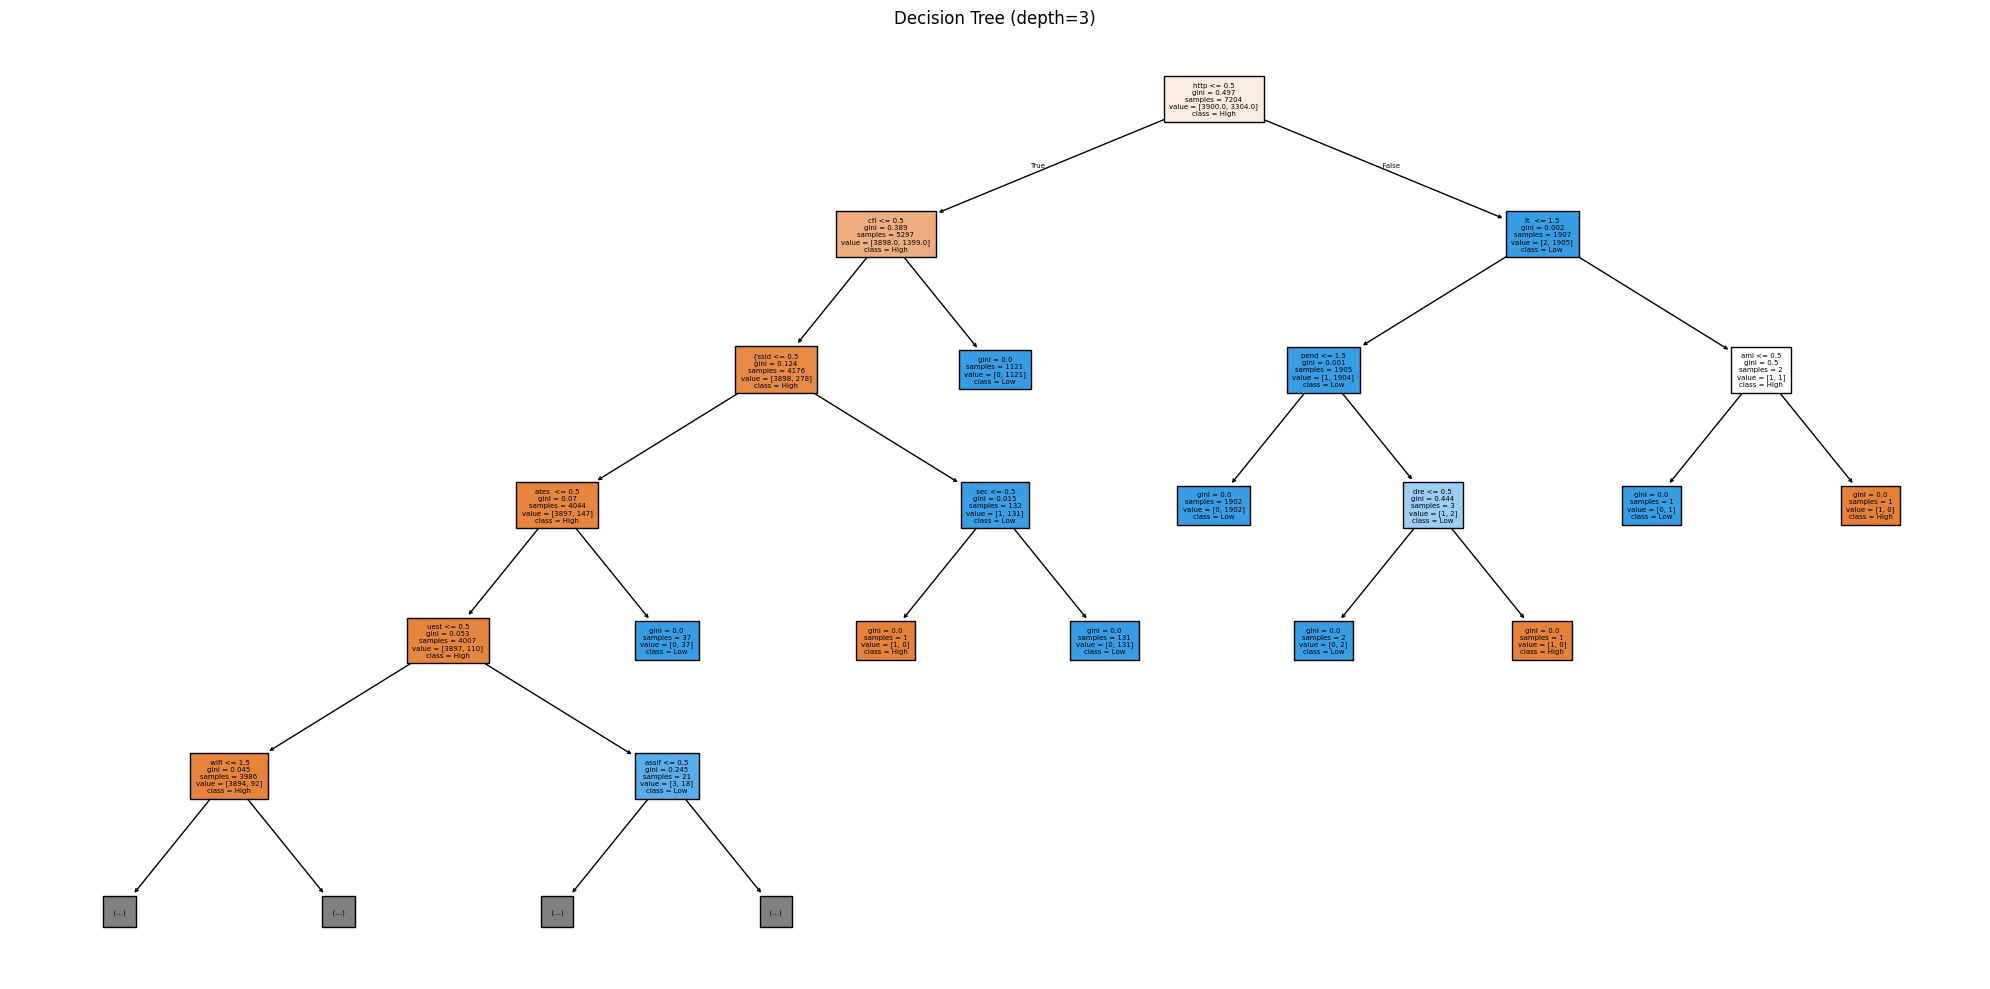

In [309]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt_model = clf_pipeline_cv.named_steps['clf']
feature_names = clf_pipeline_cv.named_steps['count_vectorizer'].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=dt_model.classes_,
    filled=True,
    max_depth=5,        # limit depth or it becomes unreadable
    fontsize=5
)
plt.title("Decision Tree (depth=3)")
plt.tight_layout()
plt.show()

In [310]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.decomposition import TruncatedSVD


clf_pipeline_knn = Pipeline([
    ("count_vectorizer", count_vectorizer),
    ("svd", TruncatedSVD(n_components=15, random_state=42)),
    ("clf", KNeighborsClassifier(n_neighbors=10))
])

clf_pipeline_knn.fit(X_train, y_train)
y_pred_knn = clf_pipeline_knn.predict(X_test)
print("=== K-Nearest Neighbors ===")
print(classification_report(y_test, y_pred_knn))

# Calculate and print F1-score and accuracy for KNN
knn_f1_macro = f1_score(y_test, y_pred_knn, average='macro')
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Macro F1-score: {knn_f1_macro:.6f}")
print(f"KNN Accuracy: {knn_accuracy:.6f}")

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

        High       0.98      0.99      0.99       975
         Low       0.99      0.98      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802

KNN Macro F1-score: 0.988257
KNN Accuracy: 0.988346


In [311]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, accuracy_score

clf_pipeline_nb = Pipeline([
    ("count_vectorizer", count_vectorizer),
    ("clf", MultinomialNB())
])

clf_pipeline_nb.fit(X_train, y_train)
y_pred_nb = clf_pipeline_nb.predict(X_test)
print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

# Calculate and print F1-score and accuracy for Naive Bayes
nb_f1_macro = f1_score(y_test, y_pred_nb, average='macro')
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Macro F1-score: {nb_f1_macro:.6f}")
print(f"Naive Bayes Accuracy: {nb_accuracy:.6f}")

=== Naive Bayes ===
              precision    recall  f1-score   support

        High       0.97      0.98      0.98       975
         Low       0.98      0.96      0.97       827

    accuracy                           0.97      1802
   macro avg       0.98      0.97      0.97      1802
weighted avg       0.97      0.97      0.97      1802

Naive Bayes Macro F1-score: 0.974260
Naive Bayes Accuracy: 0.974473


In [315]:
from sklearn.model_selection import GridSearchCV
from datetime import datetime


param_grid_dt = {
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__max_depth": [11,12,13,14],
    "clf__min_samples_split": [2,3,4],
    "clf__min_samples_leaf": [19,20,21],
    "count_vectorizer__ngram_range": [(1, 2), (2, 3), (3, 4), (3,5)],
}

grid_search = GridSearchCV(
    clf_pipeline_cv,
    param_grid=param_grid_dt,
    cv=8,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score: ", grid_search.best_score_)
print("\nClassification Report for the best model:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy: {accuracy}")

with open("TuningLogs.txt", "a") as f:
    f.write("===== DT Grid Search Results =====\n")
    f.write(f"Time: {datetime.now()}\n")
    f.write(f"Grid: {param_grid_dt}\n")
    f.write(f"Best Params: {grid_search.best_params_}\n")
    f.write(f"Best Score: {grid_search.best_score_}\n\n")


Best parameters found:  {'clf__criterion': 'entropy', 'clf__max_depth': 13, 'clf__min_samples_leaf': 19, 'clf__min_samples_split': 2, 'count_vectorizer__ngram_range': (3, 5)}
Best F1 score:  0.9920401707871789

Classification Report for the best model:
              precision    recall  f1-score   support

        High       0.99      0.99      0.99       975
         Low       0.99      0.99      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802


Accuracy: 0.9922308546059934


In [313]:
param_grid_knn = {
    "svd__n_components": [8, 9, 10],  # all must be < 53
    "clf__n_neighbors": [17, 18, 19],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan"],
    "count_vectorizer__ngram_range": [(2,3), (3,4), (3,5)],
}

grid_knn = GridSearchCV(
    clf_pipeline_knn,
    param_grid=param_grid_knn,
    cv=8,
    scoring="f1_macro",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)
best_model = grid_knn.best_estimator_
print("Best KNN params:", grid_knn.best_params_)
print("Best CV F1 Score:", grid_knn.best_score_)
print("\nClassification Report for the best model:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy: {accuracy}")

with open("TuningLogs.txt", "a") as f:
    f.write("===== KNN Grid Search Results =====\n")
    f.write(f"Grid: {param_grid_knn}\n")
    f.write(f"Best Params: {grid_knn.best_params_}\n")
    f.write(f"Best Score: {grid_knn.best_score_}\n\n")



Best KNN params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 19, 'clf__weights': 'distance', 'count_vectorizer__ngram_range': (2, 3), 'svd__n_components': 9}
Best CV F1 Score: 0.9895088222957913

Classification Report for the best model:
              precision    recall  f1-score   support

        High       0.98      1.00      0.99       975
         Low       1.00      0.98      0.99       827

    accuracy                           0.99      1802
   macro avg       0.99      0.99      0.99      1802
weighted avg       0.99      0.99      0.99      1802


Accuracy: 0.9877913429522752


In [317]:
param_grid_nb = {
    "clf__alpha": [0.06, 0.05, 0.04],
    "clf__fit_prior": [True, False],
    "clf__force_alpha": [True, False],
    "count_vectorizer__ngram_range": [(1, 2), (2, 3), (3, 4), (4,5)]

}

grid_nb = GridSearchCV(
    clf_pipeline_nb,
    param_grid=param_grid_nb,
    cv=8,
    scoring="f1_macro",
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)
best_model = grid_nb.best_estimator_

print("Best Naive Bayes params:", grid_nb.best_params_)
print("Best CV accuracy:", grid_nb.best_score_)
print("\nClassification Report for the best model:")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy: {accuracy}")

with open("TuningLogs.txt", "a") as f:
    f.write("===== NB Grid Search Results =====\n")
    f.write(f"Grid: {param_grid_nb}\n")

    f.write(f"Best Params: {grid_nb.best_params_}\n")
    f.write(f"Best Score: {grid_nb.best_score_}\n\n")



Best Naive Bayes params: {'clf__alpha': 0.05, 'clf__fit_prior': False, 'clf__force_alpha': True, 'count_vectorizer__ngram_range': (3, 4)}
Best CV accuracy: 0.9781597348316657

Classification Report for the best model:
              precision    recall  f1-score   support

        High       0.97      0.99      0.98       975
         Low       0.99      0.97      0.98       827

    accuracy                           0.98      1802
   macro avg       0.98      0.98      0.98      1802
weighted avg       0.98      0.98      0.98      1802


Accuracy: 0.9800221975582686


In [16]:
import joblib

# The best performing model was the KNN model based on the GridSearchCV results.
best_model_to_export = grid_knn.best_estimator_

# Define the filename for the exported model
model_filename = 'best_knn_model.joblib'

# Export the model
joblib.dump(best_model_to_export, model_filename)

print(f"Best model exported to {model_filename}")

Best model exported to best_knn_model.joblib


In [17]:
model2 = grid_search.best_estimator_

model_filename = 'dt.joblib'

#joblib.dump(model2, model_filename)

#print(f"Best model exported to {model_filename}")

model3 = grid_nb.best_estimator_

model_filename = 'nb.joblib'

#joblib.dump(model3, model_filename)

In [292]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd
import time

from gpt4_classification import classify_batch_with_ai
import importlib
import gpt4_classification
importlib.reload(gpt4_classification)
from gpt4_classification import classify_batch_with_ai

print("STARTING SINGLE-RUN EVALUATION WITH TIMING...")

X_full = df['Tag']
y_full = df['Sensitivity']

dt_model = grid_search.best_estimator_
knn_model = grid_knn.best_estimator_
nb_model = grid_nb.best_estimator_

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, train_size=0.8,
    random_state=42, stratify=y_full
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

results = {}

# DT
print("\n--- Decision Tree ---")
dt_model.fit(X_train, y_train)
start = time.time()
y_pred_dt = dt_model.predict(X_test)
dt_time = (time.time() - start) / len(X_test)

results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'f1_macro': f1_score(y_test, y_pred_dt, average='macro'),
    'precision': precision_score(y_test, y_pred_dt, average='macro'),
    'recall': recall_score(y_test, y_pred_dt, average='macro'),
    'avg_time_per_entry_s': dt_time
}

# KNN
print("--- KNN ---")
knn_model.fit(X_train, y_train)
start = time.time()
y_pred_knn = knn_model.predict(X_test)
knn_time = (time.time() - start) / len(X_test)

results['KNN'] = {
    'accuracy': accuracy_score(y_test, y_pred_knn),
    'f1_macro': f1_score(y_test, y_pred_knn, average='macro'),
    'precision': precision_score(y_test, y_pred_knn, average='macro'),
    'recall': recall_score(y_test, y_pred_knn, average='macro'),
    'avg_time_per_entry_s': knn_time
}

# NB
print("--- Naive Bayes ---")
nb_model.fit(X_train, y_train)
start = time.time()
y_pred_nb = nb_model.predict(X_test)
nb_time = (time.time() - start) / len(X_test)

results['Naive Bayes'] = {
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'f1_macro': f1_score(y_test, y_pred_nb, average='macro'),
    'precision': precision_score(y_test, y_pred_nb, average='macro'),
    'recall': recall_score(y_test, y_pred_nb, average='macro'),
    'avg_time_per_entry_s': nb_time
}

# GPT
print("--- AI Model (Batch Processing) ---")
X_test_list = X_test.tolist()
BATCH_SIZE = 20
ai_preds = []

#start = time.time()
#for i in range(0, len(X_test_list), BATCH_SIZE):
#    batch_texts = X_test_list[i:i+BATCH_SIZE]
#    print(f"Processing AI batch {i // BATCH_SIZE + 1}...", end='\r')
#    batch_p, _, _ = classify_batch_with_ai(batch_texts)
#    ai_preds.extend(batch_p)
#ai_time = (time.time() - start) / len(X_test_list)

print("AI Classification complete.             ")

#results['AI Model'] = {
#    'accuracy': accuracy_score(y_test, ai_preds),
#    'f1_macro': f1_score(y_test, ai_preds, average='macro'),
#    'precision': precision_score(y_test, ai_preds, average='macro'),
#    'recall': recall_score(y_test, ai_preds, average='macro'),
#  'avg_time_per_entry_s': ai_time
#}


print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

summary_df = pd.DataFrame([
    {
        'Model': model,
        'Accuracy': f"{v['accuracy']:.4f}",
        'F1-Score': f"{v['f1_macro']:.4f}",
        'Precision': f"{v['precision']:.4f}",
        'Recall': f"{v['recall']:.4f}",
        'Avg Time/Entry (s)': f"{v['avg_time_per_entry_s']:.6f}"
    }
    for model, v in results.items()
])

print(summary_df.to_string(index=False))

best_model = max(results, key=lambda x: results[x]['f1_macro'])
print(f"\n🏆 Best Model (by F1-score): {best_model}")

STARTING SINGLE-RUN EVALUATION WITH TIMING...
Train size: 7204, Test size: 1802

--- Decision Tree ---
--- KNN ---
--- Naive Bayes ---
--- AI Model (Batch Processing) ---
AI Classification complete.             

RESULTS SUMMARY
        Model Accuracy F1-Score Precision Recall Avg Time/Entry (s)
Decision Tree   0.9928   0.9927    0.9925 0.9930           0.000055
          KNN   0.9878   0.9877    0.9884 0.9871           0.000060
  Naive Bayes   0.9784   0.9782    0.9792 0.9773           0.000043

🏆 Best Model (by F1-score): Decision Tree


In [294]:
# ==========================================
# FINAL EVALUATION CELL
# Includes Decision Tree, KNN, Naive Bayes, AND AI MODEL
# ==========================================

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import precision_score, recall_score
import numpy as np
import pandas as pd
import time

# --- AI IMPORT ---
from gpt4_classification import classify_batch_with_ai

import importlib
import gpt4_classification
importlib.reload(gpt4_classification)
from gpt4_classification import classify_batch_with_ai

print("STARTING COMPREHENSIVE EVALUATION (INCLUDING AI MODEL)...")

X_full = df['Tag']
y_full = df['Sensitivity']

dt_model = grid_search.best_estimator_
knn_model = grid_knn.best_estimator_
nb_model = grid_nb.best_estimator_

print("=" * 70)
print("3-Fold Cross-Validation with Different Train-Test Splits")
print("Using the FULL dataset with 3 different 80-20 splits")
print("=" * 70)

sss = StratifiedShuffleSplit(
    n_splits=3,        # run 3 times
    test_size=0.2,     # 20% test
    train_size=0.8,    # 80% train
    random_state=42
)

# Initialize results dictionary including AI Model
results = {
    'Decision Tree': {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': []},
    'KNN': {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': []},
    'Naive Bayes': {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': []},
    'AI Model': {'accuracy': [], 'f1_macro': [], 'precision': [], 'recall': []}
}

for fold_num, (train_idx, test_idx) in enumerate(sss.split(X_full, y_full), 1):
    print(f"\n{'='*70}")
    print(f"SPLIT {fold_num} - Training on {len(train_idx)} samples, Testing on {len(test_idx)} samples")
    print(f"{'='*70}")
    
    X_train_fold = X_full.iloc[train_idx]
    X_test_fold = X_full.iloc[test_idx]
    y_train_fold = y_full.iloc[train_idx]
    y_test_fold = y_full.iloc[test_idx]

    print("Shape of X_train:", X_train_fold.shape)
    print("Shape of X_test:", X_test_fold.shape)
    print("Shape of y_train:", y_train_fold.shape)
    print("Shape of y_test:", y_test_fold.shape)
    
    print("\n--- Decision Tree ---")
    dt_model.fit(X_train_fold, y_train_fold)
    y_pred_dt = dt_model.predict(X_test_fold)
    dt_acc = accuracy_score(y_test_fold, y_pred_dt)
    dt_f1 = f1_score(y_test_fold, y_pred_dt, average='macro')
    dt_precision = precision_score(y_test_fold, y_pred_dt, average='macro')
    dt_recall = recall_score(y_test_fold, y_pred_dt, average='macro')
    
    results['Decision Tree']['accuracy'].append(dt_acc)
    results['Decision Tree']['f1_macro'].append(dt_f1)
    results['Decision Tree']['precision'].append(dt_precision)
    results['Decision Tree']['recall'].append(dt_recall)
    
    print(f"Accuracy: {dt_acc:.4f}, F1: {dt_f1:.4f}, Precision: {dt_precision:.4f}, Recall: {dt_recall:.4f}")
    
    print("\n--- K-Nearest Neighbors ---")
    knn_model.fit(X_train_fold, y_train_fold)
    y_pred_knn = knn_model.predict(X_test_fold)
    knn_acc = accuracy_score(y_test_fold, y_pred_knn)
    knn_f1 = f1_score(y_test_fold, y_pred_knn, average='macro')
    knn_precision = precision_score(y_test_fold, y_pred_knn, average='macro')
    knn_recall = recall_score(y_test_fold, y_pred_knn, average='macro')
    
    results['KNN']['accuracy'].append(knn_acc)
    results['KNN']['f1_macro'].append(knn_f1)
    results['KNN']['precision'].append(knn_precision)
    results['KNN']['recall'].append(knn_recall)
    
    print(f"Accuracy: {knn_acc:.4f}, F1: {knn_f1:.4f}, Precision: {knn_precision:.4f}, Recall: {knn_recall:.4f}")
    
    print("\n--- Naive Bayes ---")
    nb_model.fit(X_train_fold, y_train_fold)
    y_pred_nb = nb_model.predict(X_test_fold)
    nb_acc = accuracy_score(y_test_fold, y_pred_nb)
    nb_f1 = f1_score(y_test_fold, y_pred_nb, average='macro')
    nb_precision = precision_score(y_test_fold, y_pred_nb, average='macro')
    nb_recall = recall_score(y_test_fold, y_pred_nb, average='macro')
    
    results['Naive Bayes']['accuracy'].append(nb_acc)
    results['Naive Bayes']['f1_macro'].append(nb_f1)
    results['Naive Bayes']['precision'].append(nb_precision)
    results['Naive Bayes']['recall'].append(nb_recall)
    
    print(f"Accuracy: {nb_acc:.4f}, F1: {nb_f1:.4f}, Precision: {nb_precision:.4f}, Recall: {nb_recall:.4f}")

    # --- AI Model Integration ---
    print("\n--- AI Model (Batch Processing) ---")
    # We need to process the fold in batches to respect the token limits/design
    ai_preds = []
    
    # Convert series to list for batching
    X_test_list = X_test_fold.tolist()
    
    BATCH_SIZE = 20
    total_ai = len(X_test_list)
    
   # for i in range(0, total_ai, BATCH_SIZE):
   #     batch_texts = X_test_list[i:i+BATCH_SIZE]
   #     print(f"Processing AI batch {i // BATCH_SIZE + 1}...", end='\r')
   #     # CALLING THE IMPORTED FUNCTION
   #     batch_p, _, _ = classify_batch_with_ai(batch_texts)
   #     ai_preds.extend(batch_p)
    
    print("AI Classification complete.             ")
    
    # Calculate metrics for AI
    ai_acc = 0 # accuracy_score(y_test_fold, ai_preds)
    ai_f1 = 0 #f1_score(y_test_fold, ai_preds, average='macro')
    ai_precision =0 # precision_score(y_test_fold, ai_preds, average='macro')
    ai_recall = 0 #recall_score(y_test_fold, ai_preds, average='macro')
    
    results['AI Model']['accuracy'].append(ai_acc)
    results['AI Model']['f1_macro'].append(ai_f1)
    results['AI Model']['precision'].append(ai_precision)
    results['AI Model']['recall'].append(ai_recall)
    
    print(f"Accuracy: {ai_acc:.4f}, F1: {ai_f1:.4f}, Precision: {ai_precision:.4f}, Recall: {ai_recall:.4f}")

    
    print(f"\n--- Split {fold_num} Summary ---")
    split_comparison = pd.DataFrame({
        'Model': ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model'],
        'Accuracy': [dt_acc, knn_acc, nb_acc, ai_acc],
        'F1-Score': [dt_f1, knn_f1, nb_f1, ai_f1],
        'Precision': [dt_precision, knn_precision, nb_precision, ai_precision],
        'Recall': [dt_recall, knn_recall, nb_recall, ai_recall]
    })
    print(split_comparison.to_string(index=False))
    best_model = split_comparison.loc[split_comparison['Accuracy'].idxmax(), 'Model']
    print(f"\nBest model for Split {fold_num}: {best_model}")


print("\n" + "=" * 70)
print("COMPREHENSIVE SUMMARY - All Train-Test Splits")
print("=" * 70)

# Per-split comparison table
summary_data = []
for fold_num in range(1, 4):
    summary_data.append({
        'Split': fold_num,
        'DT_Acc': f"{results['Decision Tree']['accuracy'][fold_num-1]:.4f}",
        'DT_F1': f"{results['Decision Tree']['f1_macro'][fold_num-1]:.4f}",
        'KNN_Acc': f"{results['KNN']['accuracy'][fold_num-1]:.4f}",
        'KNN_F1': f"{results['KNN']['f1_macro'][fold_num-1]:.4f}",
        'NB_Acc': f"{results['Naive Bayes']['accuracy'][fold_num-1]:.4f}",
        'NB_F1': f"{results['Naive Bayes']['f1_macro'][fold_num-1]:.4f}",
        'AI_Acc': f"{results['AI Model']['accuracy'][fold_num-1]:.4f}",
        'AI_F1': f"{results['AI Model']['f1_macro'][fold_num-1]:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nPer-Split Performance:")
print(summary_df.to_string(index=False))

print("\n" + "=" * 70)
print("OVERALL STATISTICS (Mean ± Std)")
print("=" * 70)

stats_data = []
for model_name in ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model']:
    acc_mean = np.mean(results[model_name]['accuracy'])
    acc_std = np.std(results[model_name]['accuracy'])
    f1_mean = np.mean(results[model_name]['f1_macro'])
    f1_std = np.std(results[model_name]['f1_macro'])
    prec_mean = np.mean(results[model_name]['precision'])
    prec_std = np.std(results[model_name]['precision'])
    rec_mean = np.mean(results[model_name]['recall'])
    rec_std = np.std(results[model_name]['recall'])
    
    stats_data.append({
        'Model': model_name,
        'Accuracy': f"{acc_mean:.4f} ± {acc_std:.4f}",
        'F1-Score': f"{f1_mean:.4f} ± {f1_std:.4f}",
        'Precision': f"{prec_mean:.4f} ± {prec_std:.4f}",
        'Recall': f"{rec_mean:.4f} ± {rec_std:.4f}"
    })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))

best_overall = max(
    ['Decision Tree', 'KNN', 'Naive Bayes', 'AI Model'],
    key=lambda x: np.mean(results[x]['f1_macro'])
)
print(f"\n🏆 Best Overall Model (by mean F1-score): {best_overall}")

STARTING COMPREHENSIVE EVALUATION (INCLUDING AI MODEL)...
3-Fold Cross-Validation with Different Train-Test Splits
Using the FULL dataset with 3 different 80-20 splits

SPLIT 1 - Training on 7204 samples, Testing on 1802 samples
Shape of X_train: (7204,)
Shape of X_test: (1802,)
Shape of y_train: (7204,)
Shape of y_test: (1802,)

--- Decision Tree ---
Accuracy: 0.9928, F1: 0.9927, Precision: 0.9925, Recall: 0.9930

--- K-Nearest Neighbors ---
Accuracy: 0.9878, F1: 0.9877, Precision: 0.9884, Recall: 0.9871

--- Naive Bayes ---
Accuracy: 0.9784, F1: 0.9782, Precision: 0.9792, Recall: 0.9773

--- AI Model (Batch Processing) ---
AI Classification complete.             
Accuracy: 0.0000, F1: 0.0000, Precision: 0.0000, Recall: 0.0000

--- Split 1 Summary ---
        Model  Accuracy  F1-Score  Precision   Recall
Decision Tree  0.992786  0.992740   0.992529 0.992966
          KNN  0.987791  0.987692   0.988440 0.987066
  Naive Bayes  0.978357  0.978170   0.979224 0.977339
     AI Model  0.0000

In [19]:

print("\n" + "="*70)
print("MODEL COMPARISON & IMPROVEMENT ANALYSIS")
print("="*70)

# 1. Calculate Mean Metrics for each model
mean_metrics = {}
for model in results:
    mean_metrics[model] = {
        'Accuracy': np.mean(results[model]['accuracy']),
        'F1-Score': np.mean(results[model]['f1_macro']),
        'Precision': np.mean(results[model]['precision']),
        'Recall': np.mean(results[model]['recall'])
    }

metrics_df = pd.DataFrame(mean_metrics).T
print("\n--- Average Performance Metrics ---")
print(metrics_df)

# 2. Identify the Baseline Model (e.g., Decision Tree or the worst performer)
# Or compares Best Model vs Others.
# Let's compare "Best Overall" (already identified) vs others.

best_model_name = best_overall # From previous cell
print(f"\nComparing all models against the Best Performer: {best_model_name}")

improvement_data = []

exclude_models = [best_model_name]
baseline_metrics = mean_metrics[best_model_name]

for model in mean_metrics:
    if model == best_model_name:
        continue
    
    row = {'Model': model}
    for metric in ['Accuracy', 'F1-Score', 'Precision', 'Recall']:
        # Improvement: (Best - Other) / Other * 100
        # If Best is higher, it's positive improvement. 
        # If Other is 0 (unlikely but possible for broken models), handle it.
        
        other_val = mean_metrics[model][metric]
        best_val = baseline_metrics[metric]
        
        if other_val == 0:
            imp = float('inf')
        else:
            imp = ((best_val - other_val) / other_val) * 100
            
        row[f'{metric} Improvement (%)'] = f"{imp:+.2f}%"
        
    improvement_data.append(row)

imp_df = pd.DataFrame(improvement_data)
print(f"\n--- Improvement of {best_model_name} over other models ---")
print(imp_df.to_string(index=False))

# 3. Pairwise Matrix (Optional but detailed)
# metric = 'F1-Score'
# print(f"\n--- Pairwise {metric} Improvement Matrix (Row vs Column) ---")
# matrix_data = {}
# for row_model in mean_metrics:
#     matrix_data[row_model] = {}
#     for col_model in mean_metrics:
#         val_row = mean_metrics[row_model][metric]
#         val_col = mean_metrics[col_model][metric]
#         if val_col == 0:
#              perc = np.nan
#         else:
#              perc = ((val_row - val_col) / val_col) * 100
#         matrix_data[row_model][col_model] = f"{perc:+.2f}%"

# print(pd.DataFrame(matrix_data))



MODEL COMPARISON & IMPROVEMENT ANALYSIS

--- Average Performance Metrics ---
               Accuracy  F1-Score  Precision    Recall
Decision Tree  0.988346  0.988272   0.988123  0.988466
KNN            0.971328  0.971122   0.971361  0.970935
Naive Bayes    0.774140  0.760957   0.803552  0.760048
AI Model       0.814650  0.813828   0.813392  0.814676

Comparing all models against the Best Performer: Decision Tree

--- Improvement of Decision Tree over other models ---
      Model Accuracy Improvement (%) F1-Score Improvement (%) Precision Improvement (%) Recall Improvement (%)
        KNN                   +1.75%                   +1.77%                    +1.73%                 +1.81%
Naive Bayes                  +27.67%                  +29.87%                   +22.97%                +30.05%
   AI Model                  +21.32%                  +21.43%                   +21.48%                +21.33%
